# Mosaíco dos gráficos 

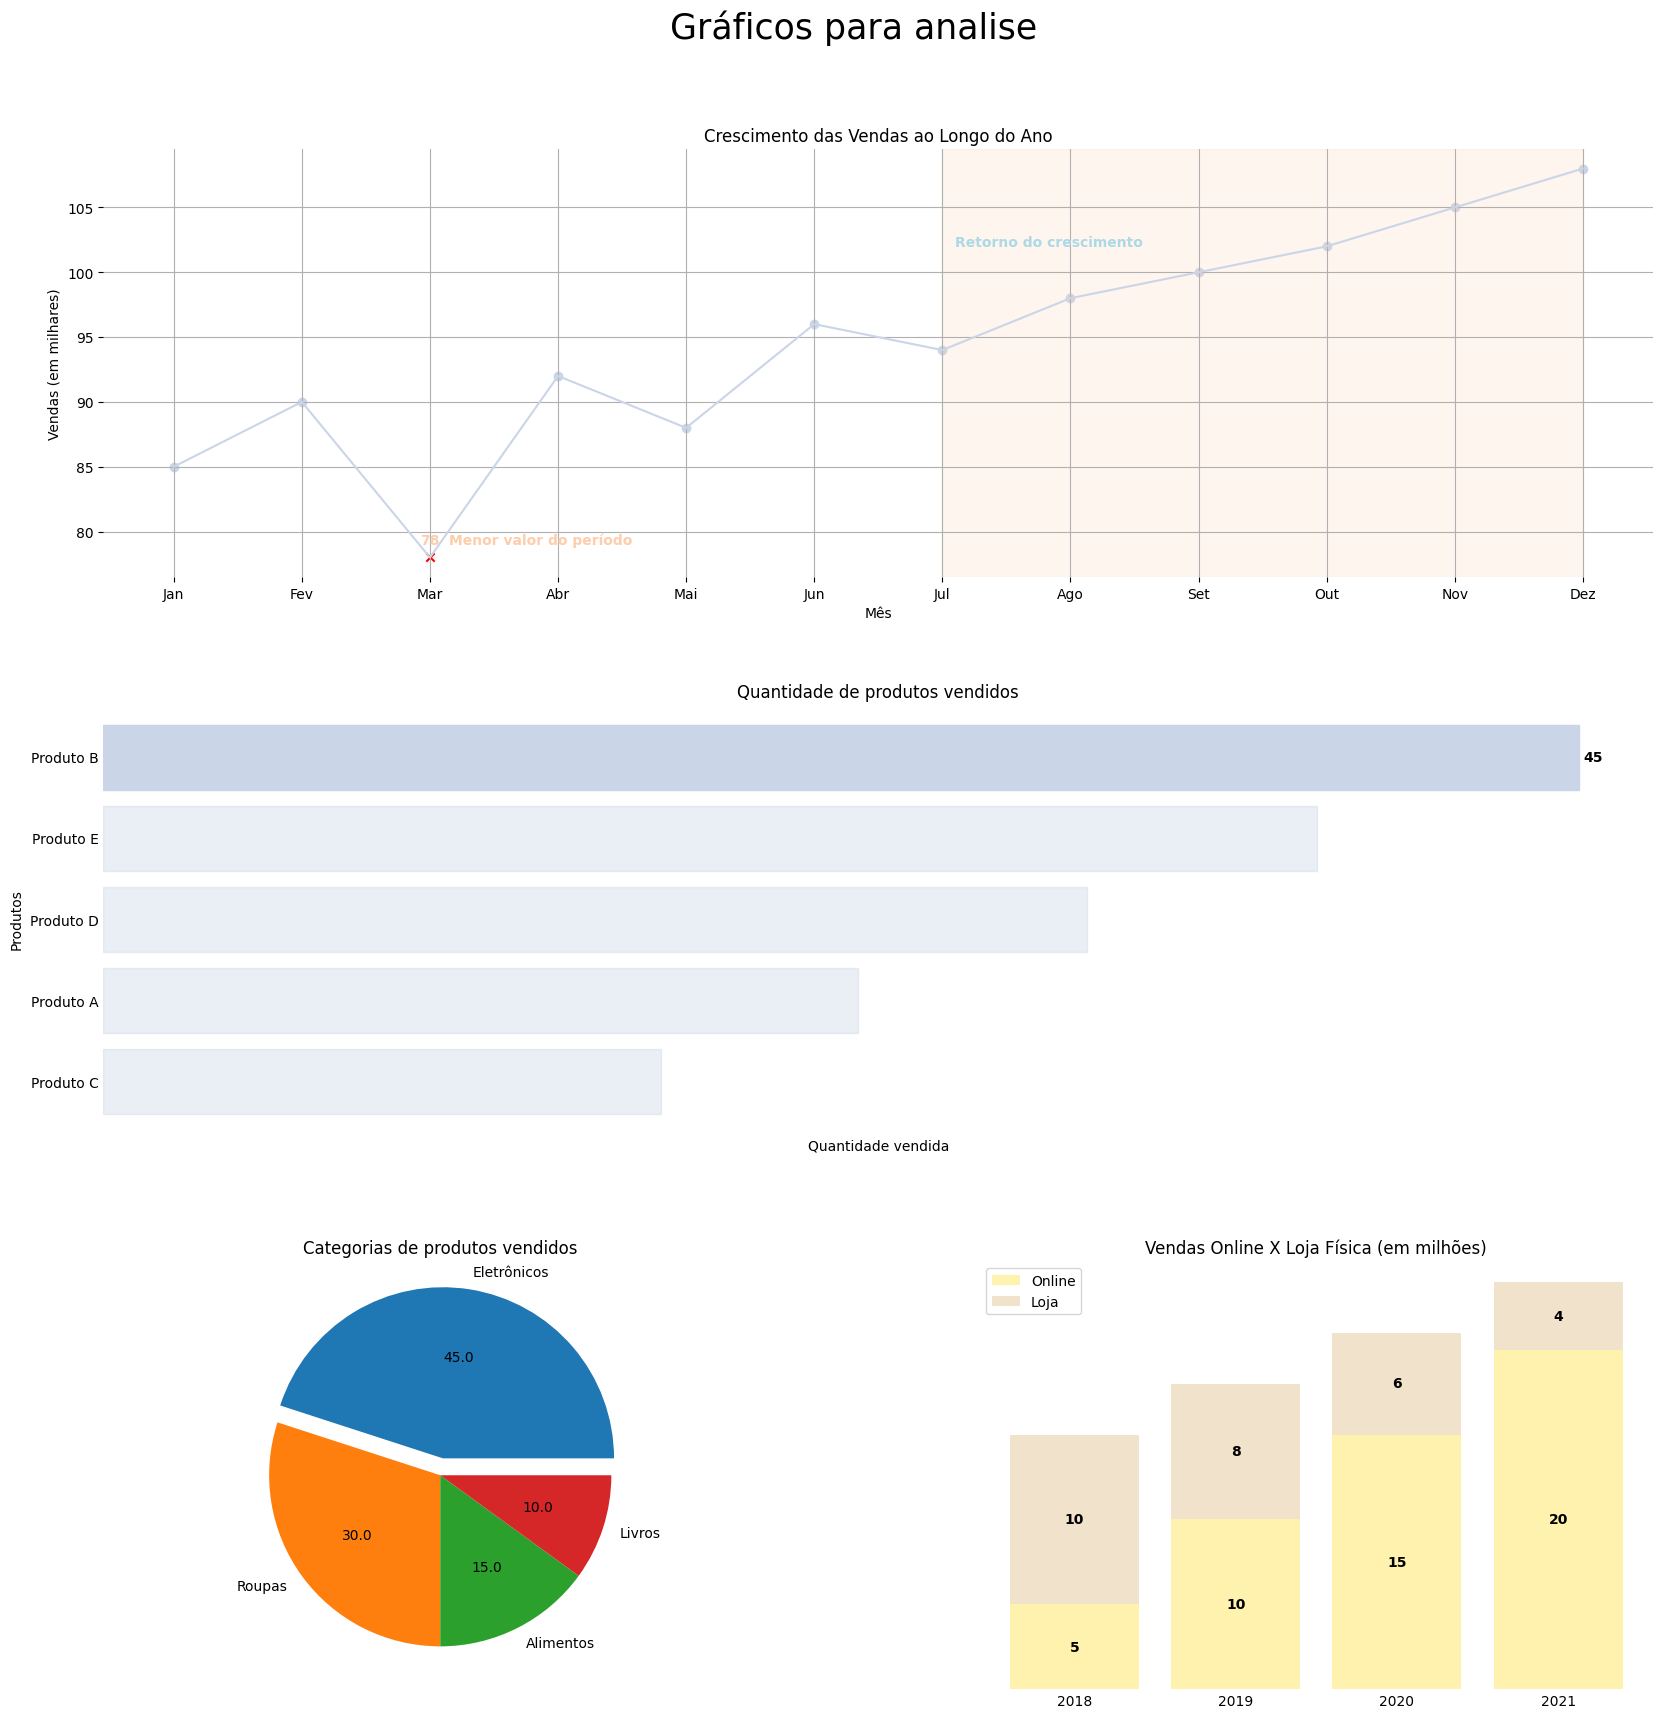

In [1]:
import matplotlib.pyplot as plt
from cycler import cycler
import numpy as np

espacamento = {'wspace':0.3,'hspace':0.3}
mosaico = 'AA;BB;CD'
fig = plt.figure(figsize=(20,20))
axs = fig.subplot_mosaic(mosaico, gridspec_kw=espacamento)


#paleta de cores
cores = plt.get_cmap('Pastel2').colors
ciclo_cores = cycler('color', cores)
plt.rc('axes', prop_cycle = ciclo_cores)

fig.suptitle('Gráficos para analise', fontsize=25, y=0.95)

# Gráficio 1 ----------------------------------------------

meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
vendas = [85, 90, 78, 92, 88, 96, 94, 98, 100, 102, 105, 108]

#gráfico

axs['A'].plot(meses, vendas, color = cores[2])

marcadores = np.where(vendas == np.min(vendas), 'x', 'o')

for posicao, marcador in enumerate(marcadores):
    if marcador == 'x':
        cor = 'red'
    else:
        cor = cores[2]
    axs['A'].scatter(meses[posicao], vendas[posicao], marker=marcador, color=cor)


# Anotações
axs['A'].annotate(np.min(vendas), color = cores[1], xy = (2, 78), xytext = (1.92, 79), fontweight = 'bold')
axs['A'].annotate('Menor valor do período', color = cores[1], xy = (2, 78), xytext = (2.15, 79), fontweight = 'bold')
axs['A'].annotate('Retorno do crescimento', color ='lightblue', xy = (2, 78), xytext = (6.1, 102), fontweight = 'bold')

#destaques
axs['A'].axvspan(6, 11, color = cores[1], alpha = 0.2)

axs['A'].set_xlabel('Mês')
axs['A'].set_ylabel('Vendas (em milhares)')
axs['A'].set_title('Crescimento das Vendas ao Longo do Ano')
axs['A'].set_frame_on(False)

axs['A'].grid(True)


# Gráficio 2----------------------------------------------

produtos = ['Produto A', 'Produto B', 'Produto C', 'Produto D', 'Produto E']
quantidades = [23, 45, 17, 30, 37]
dados_ordenados = sorted(zip(quantidades, produtos))
quantidades_ordenadas = [x[0] for x in dados_ordenados]
produtos_ordenados = [x[1] for x in dados_ordenados]


barras = axs['B'].barh(produtos_ordenados, quantidades_ordenadas)

axs['B'].set_title('Quantidade de produtos vendidos')
axs['B'].set_ylabel('Produtos')
axs['B'].set_xlabel('Quantidade vendida')

axs['B'].bar_label (barras, labels=[max(quantidades_ordenadas) if x == max(quantidades_ordenadas) else '' for x in quantidades_ordenadas], padding = 3, fontsize = 10, fontweight = 'bold')

# Retirando a borda
axs['B'].set_frame_on(False)

# Removendo ticks
axs['B'].set_xticks([])
axs['B'].tick_params(axis='y', length = 0)

# Cor das barras
for i, barra in enumerate(barras):
    cor_barras = cores[2]
    if i != quantidades_ordenadas.index(max(quantidades_ordenadas)):
        barras[i].set_color(cor_barras)
        barras[i].set_alpha(0.4)
    else:
        barras[i].set_color(cor_barras)

# Gráficio 3----------------------------------------------

categorias = ['Eletrônicos', 'Roupas', 'Alimentos', 'Livros']
quantidades_vendidas = [45, 30, 15, 10]
destaque = [0.1, 0, 0, 0]  # destacar a primeira fatia

axs['C'].pie(quantidades_vendidas, labels=categorias, explode=destaque, autopct='%.1f')
axs['C'].set_title('Categorias de produtos vendidos')

# Gráficio 4----------------------------------------------

anos = [2018, 2019, 2020, 2021]
vendas_online = [5, 10, 15, 20]
vendas_loja = [10, 8, 6, 4]

barras_online = axs['D'].bar(anos, vendas_online, label='Online', color = cores[5])
barras_loja = axs['D'].bar(anos, vendas_loja, bottom=vendas_online, label='Loja', color = cores[6])

axs['D'].bar_label(barras_loja, labels = vendas_loja, label_type = 'center', fontweight='bold')

axs['D'].bar_label(barras_online, labels = vendas_online, label_type = 'center', fontweight='bold')

# forçar os anos a serem exibidos como inteiros
axs['D'].set_xticks(ticks=anos)

# Desativando Caixa
axs['D'].set_frame_on(False)

axs['D'].set_title('Vendas Online X Loja Física (em milhões)')
axs['D'].legend()
axs['D'].set_yticks([])
axs['D'].tick_params(axis = 'x', length=0)


plt.show()